In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from data_prep import load_merged, temporal_split
from eval_harness import evaluate
from features import (categorical_columns, fit_categories,
                      apply_categories, add_time_features, feature_list)

df = load_merged("../data/raw")
train, val, test = temporal_split(df)

cat_cols = categorical_columns(train)
vocab = fit_categories(train, cat_cols)
train = add_time_features(apply_categories(train, vocab))
val   = add_time_features(apply_categories(val, vocab))

feats = feature_list(train)
y_train, y_val = train["isFraud"], val["isFraud"]

model = XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=-1,
                      random_state=42, enable_categorical=True)
model.fit(train[feats], y_train)
proba_val = model.predict_proba(val[feats])[:, 1]

print(evaluate(y_val, proba_val, name="nb04 model, rebuilt"))  # expect PR-AUC ≈ 0.577


{'name': 'nb04 model, rebuilt', 'pr_auc': 0.577, 'roc_auc': 0.9073, 'threshold': 0.5, 'recall': np.float64(0.3869), 'precision': np.float64(0.7894), 'flagged': 2260, 'missed_fraud': 2827}


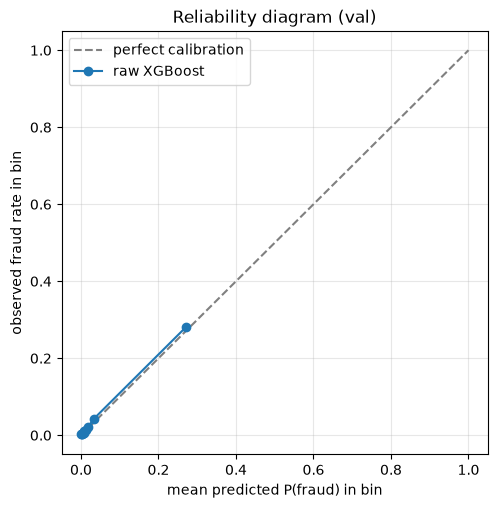

Brier score (lower=better): 0.02370
mean predicted: 0.0362   true rate: 0.0390


In [6]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

frac_pos, mean_pred = calibration_curve(y_val, proba_val,
                                        n_bins=10, strategy="quantile")

plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", color="grey", label="perfect calibration")
plt.plot(mean_pred, frac_pos, "o-", label="raw XGBoost")
plt.xlabel("mean predicted P(fraud) in bin")
plt.ylabel("observed fraud rate in bin")
plt.title("Reliability diagram (val)")
plt.legend(); plt.grid(alpha=.3)
plt.savefig("../reports/figures/reliability_raw.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Brier score (lower=better): {brier_score_loss(y_val, proba_val):.5f}")
print(f"mean predicted: {proba_val.mean():.4f}   true rate: {y_val.mean():.4f}")


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.isotonic import IsotonicRegression

half = len(val) // 2
cal_idx, chk_idx = np.arange(half), np.arange(half, len(val))
p_cal, y_cal = proba_val[cal_idx], y_val.iloc[cal_idx]
p_chk, y_chk = proba_val[chk_idx], y_val.iloc[chk_idx]

# --- Platt scaling: logistic regression on the log-odds of the score ---
def logit(p, eps=1e-6):
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))

platt = LogisticRegression().fit(logit(p_cal).reshape(-1, 1), y_cal)
p_chk_platt = platt.predict_proba(logit(p_chk).reshape(-1, 1))[:, 1]

# --- Isotonic regression: best-fit monotone step function ---
iso = IsotonicRegression(out_of_bounds="clip").fit(p_cal, y_cal)
p_chk_iso = iso.predict(p_chk)


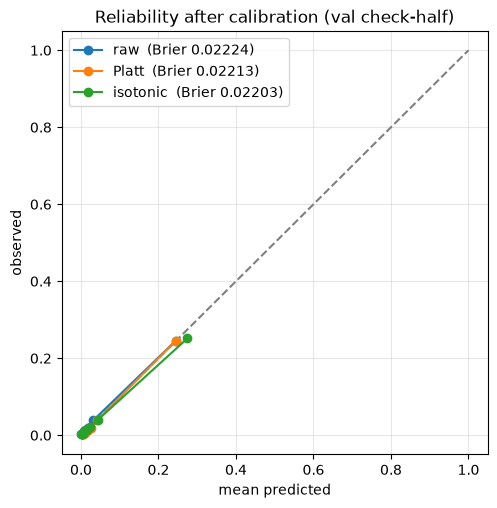

raw       PR-AUC on check half: 0.5454
Platt     PR-AUC on check half: 0.5454
isotonic  PR-AUC on check half: 0.5344


In [4]:
from sklearn.metrics import average_precision_score

plt.figure(figsize=(5.5, 5.5))
plt.plot([0, 1], [0, 1], "--", color="grey")
for p, label in [(p_chk, "raw"), (p_chk_platt, "Platt"), (p_chk_iso, "isotonic")]:
    fp, mp = calibration_curve(y_chk, p, n_bins=10, strategy="quantile")
    plt.plot(mp, fp, "o-", label=f"{label}  (Brier {brier_score_loss(y_chk, p):.5f})")
plt.xlabel("mean predicted"); plt.ylabel("observed")
plt.title("Reliability after calibration (val check-half)")
plt.legend(); plt.grid(alpha=.3); plt.show()

# calibration must NOT change the ranking:
for p, label in [(p_chk, "raw"), (p_chk_platt, "Platt"), (p_chk_iso, "isotonic")]:
    print(f"{label:9s} PR-AUC on check half: {average_precision_score(y_chk, p):.4f}")


In [5]:
print(len(feats), "features")
print("hour/dow present:", "hour" in feats, "dow" in feats)
print("categorical count:", sum(str(train[c].dtype) == "category" for c in feats))

# and the deeper question: how much does PR-AUC wobble for BENIGN reasons?
from sklearn.metrics import average_precision_score
for seed in (0, 1, 2):
    m = XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=-1,
                      random_state=seed, enable_categorical=True)
    m.fit(train[feats], y_train)
    p = m.predict_proba(val[feats])[:, 1]
    print(f"seed {seed}: PR-AUC {average_precision_score(y_val, p):.4f}")


434 features
hour/dow present: True True
categorical count: 31
seed 0: PR-AUC 0.5770
seed 1: PR-AUC 0.5770
seed 2: PR-AUC 0.5770


In [ ]:
## Findings

1. **Reproducibility check caught a real extraction bug.** The `src/` rebuild initially
   scored 0.551 vs notebook 04's 0.577 — the categorical selector matched `str` dtype but
   not post-cast `category` dtype, silently dropping all 31 categorical features. Classic
   train/serve-skew bug; found only because cell 1 asserts the expected score. Fixed;
   0.577 reproduced exactly.
2. **Raw XGBoost scores are already near-calibrated**: diagonal reliability curve, mean
   predicted 0.036 vs true rate 0.039, Brier 0.0237 (naive base-rate predictor: 0.0375).
   Expected from theory — log-loss is a proper scoring rule and we train on the true,
   unweighted distribution. The nb03 weighted model (scores 5× inflated) would have
   needed real repair; the untreated model doesn't. Decisions compound.
3. **Calibration is ranking-invariant, verified**: Platt PR-AUC = raw to 4 decimals.
   Isotonic costs 0.011 PR-AUC (step-function ties) to gain ~1% Brier.
4. **Decision: ship raw scores.** Calibration was verified, not needed; a calibrator
   artifact isn't worth 1% Brier. Reliability diagram is the evidence.
5. Drift, third sighting: PR-AUC 0.577 (full val) → 0.545 (latest half of val).
6. Model training is fully deterministic with our config (`random_state` inert without
   subsampling) — split-to-split variance remains unquantified (open caveat).
